# Exploratory Data Analysis

This notebook explores the FDA datasets to understand patterns,
distributions, and relationships relevant to predicting supplier non-compliance.

**Scope**: Drugs, Devices, Biologics, Veterinary, Tobacco, and Cosmetics.
Pure food-related inspections are excluded.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

DATA_RAW = Path("../data/raw")

## 1. Load and filter data

In [2]:
# Load inspections
inspections = pd.read_excel(DATA_RAW / "inspections.xlsx")
print(f"Total inspections: {len(inspections):,}")

# Exclude pure food Project Areas
FOOD_ONLY_AREAS = [
    "Foodborne Biological Hazards",
    "Food Composition, Standards, Labeling and Econ",
    "Pesticides and Chemical Contaminants",
    "Food and Color Additives Petition Review",
]

inspections = inspections[~inspections["Project Area"].isin(FOOD_ONLY_AREAS)].copy()
print(f"After excluding pure food: {len(inspections):,}")
print(f"\nProduct Type distribution:")
print(inspections["Product Type"].value_counts())

Total inspections: 337,519
After excluding pure food: 165,052

Product Type distribution:
Product Type
Devices           50008
Drugs             39521
Biologics         31969
Veterinary        26291
Food/Cosmetics    16003
Tobacco            1260
Name: count, dtype: int64


In [3]:
# Load citations
citations = pd.read_excel(DATA_RAW / "citations.xlsx")
print(f"Total citations: {len(citations):,}")

# Filter to only inspections in our scope
valid_inspection_ids = set(inspections["Inspection ID"])
citations = citations[citations["Inspection ID"].isin(valid_inspection_ids)].copy()
print(f"After filtering to in-scope inspections: {len(citations):,}")

Total citations: 277,463
After filtering to in-scope inspections: 130,992


In [4]:
# Load warning letters
with open(DATA_RAW / "warning_letters.json") as f:
    warning_letters = pd.DataFrame(json.load(f))
print(f"Warning letters: {len(warning_letters):,}")
print(warning_letters["issuing_office"].value_counts().head(5))

Warning letters: 3,608
issuing_office
Center for Tobacco Products                             1197
Center for Drug Evaluation and Research (CDER)           580
Center for Drug Evaluation and Research | CDER           344
Center for Devices and Radiological Health               217
Center for Food Safety and Applied Nutrition (CFSAN)     108
Name: count, dtype: int64


In [5]:
# Load enforcement (drug + device only, skip food)
# Only keep fields we need to avoid OOM with the 400MB device file
ENFORCEMENT_FIELDS = [
    "recalling_firm", "classification", "city", "state", "country",
    "product_type", "recall_initiation_date", "reason_for_recall",
    "voluntary_mandated", "status",
]

enforcement_records = []
for product in ["drug", "device"]:
    with open(DATA_RAW / f"{product}-enforcement-0001-of-0001.json") as f:
        data = json.load(f)
    for r in data["results"]:
        record = {k: r.get(k, "") for k in ENFORCEMENT_FIELDS}
        record["_source"] = product
        enforcement_records.append(record)
    del data

enforcement = pd.DataFrame(enforcement_records)
del enforcement_records
print(f"Enforcement records (drug + device): {len(enforcement):,}")

Enforcement records (drug + device): 57,203


## 2. Inspections overview

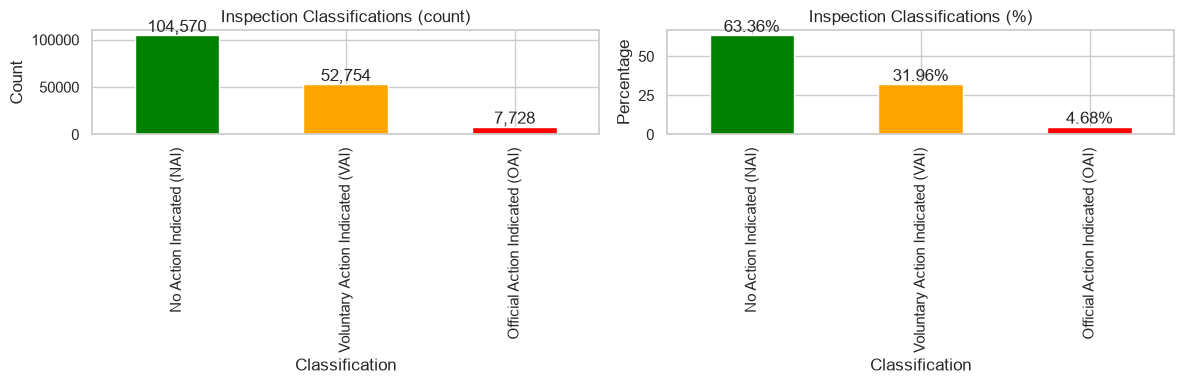

In [6]:
# Classification distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

inspections["Classification"].value_counts().plot(
    kind="bar", ax=axes[0], color=["green", "orange", "red"]
)
axes[0].set_title("Inspection Classifications (count)")
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: f'{x:,.0f}')

pcts = inspections["Classification"].value_counts(normalize=True) * 100
pcts.plot(kind="bar", ax=axes[1], color=["green", "orange", "red"])
axes[1].set_title("Inspection Classifications (%)")
axes[1].set_ylabel("Percentage")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.savefig("../reports/fig_classification_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

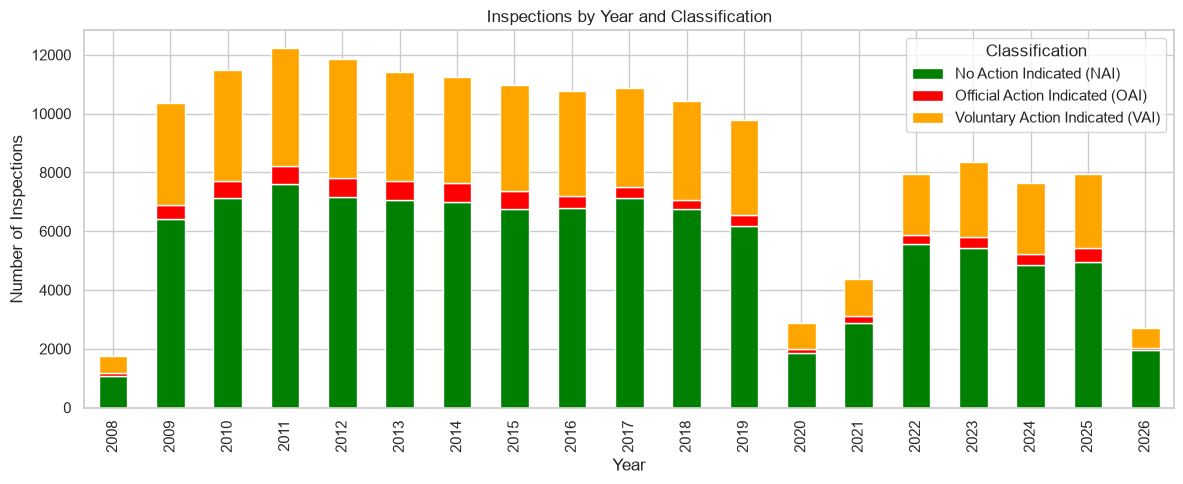

In [7]:
# Inspections over time
inspections["Inspection End Date"] = pd.to_datetime(inspections["Inspection End Date"])
inspections["year"] = inspections["Inspection End Date"].dt.year

yearly = inspections.groupby(["year", "Classification"]).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2008]

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind="bar", stacked=True, ax=ax, color=["green", "red", "orange"])
ax.set_title("Inspections by Year and Classification")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Inspections")
ax.legend(title="Classification")
plt.tight_layout()
plt.savefig("../reports/fig_inspections_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

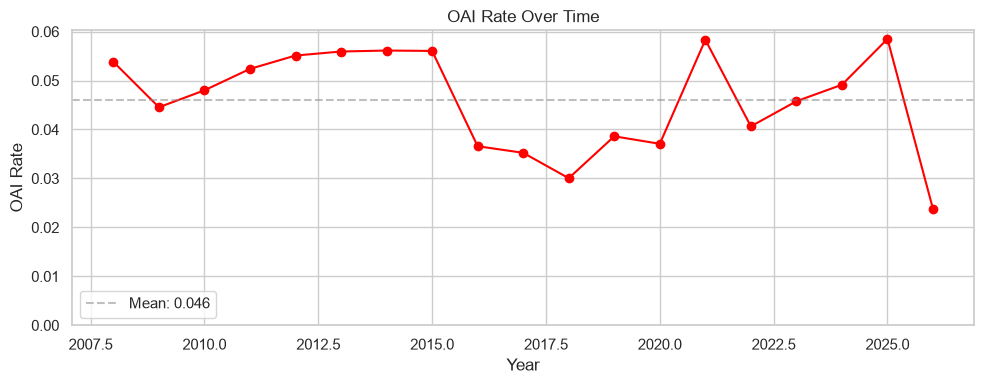

In [8]:
# OAI rate over time
oai_rate = inspections[inspections["year"] >= 2008].groupby("year").apply(
    lambda g: (g["Classification"] == "Official Action Indicated (OAI)").mean()
)
fig, ax = plt.subplots(figsize=(10, 4))
oai_rate.plot(ax=ax, marker="o", color="red")
ax.set_title("OAI Rate Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("OAI Rate")
ax.set_ylim(0, None)
ax.axhline(oai_rate.mean(), color="gray", linestyle="--", alpha=0.5, label=f"Mean: {oai_rate.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/fig_oai_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# By Product Type
product_class = inspections.groupby(["Product Type", "Classification"]).size().unstack(fill_value=0)
product_class["OAI_rate"] = product_class.get("Official Action Indicated (OAI)", 0) / product_class.sum(axis=1)
print("OAI rate by Product Type:")
print(product_class["OAI_rate"].sort_values(ascending=False))

OAI rate by Product Type:
Product Type
Tobacco           0.122222
Drugs             0.075985
Devices           0.059450
Veterinary        0.045985
Biologics         0.009322
Food/Cosmetics    0.005686
Name: OAI_rate, dtype: float64


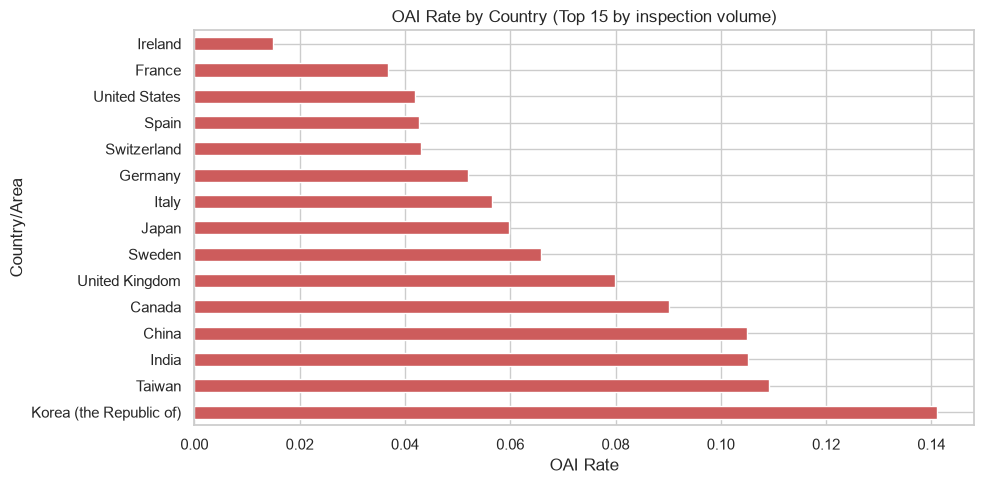

In [10]:
# By Country (top 15)
top_countries = inspections["Country/Area"].value_counts().head(15).index
country_oai = inspections[inspections["Country/Area"].isin(top_countries)].groupby("Country/Area").apply(
    lambda g: (g["Classification"] == "Official Action Indicated (OAI)").mean()
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
country_oai.plot(kind="barh", ax=ax, color="indianred")
ax.set_title("OAI Rate by Country (Top 15 by inspection volume)")
ax.set_xlabel("OAI Rate")
plt.tight_layout()
plt.savefig("../reports/f   ig_oai_rate_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Repeat offenders

In [11]:
# Facilities with most OAI inspections
oai_inspections = inspections[inspections["Classification"] == "Official Action Indicated (OAI)"]
repeat_offenders = oai_inspections.groupby("FEI Number").agg(
    legal_name=("Legal Name", "first"),
    n_oai=("Classification", "count"),
    country=("Country/Area", "first"),
    product_type=("Product Type", "first"),
    last_oai=("Inspection End Date", "max"),
).sort_values("n_oai", ascending=False)

print(f"Unique facilities with at least 1 OAI: {len(repeat_offenders):,}")
print(f"Facilities with 3+ OAIs: {(repeat_offenders['n_oai'] >= 3).sum():,}")
print(f"\nTop 15 repeat offenders:")
print(repeat_offenders.head(15).to_string())

Unique facilities with at least 1 OAI: 5,149
Facilities with 3+ OAIs: 497

Top 15 repeat offenders:


                                                                                legal_name  n_oai        country product_type   last_oai
FEI Number                                                                                                                              
1950222     Meridian Medical Technologies, LLC a Subsidiary of Kindeva Drug Delivery, L.P.     14  United States      Devices 2019-12-21
3006228598                                                      Wells Pharmacy Network LLC     13  United States        Drugs 2016-09-13
3005350897                                                               Belleview 402 LLC     12  United States        Drugs 2024-03-15
3010892830                                                                 Nephron SC, LLC     11  United States        Drugs 2024-09-25
2242352                                                         Maquet Cardiovascular, LLC     11  United States      Devices 2024-07-11
2518422                                  

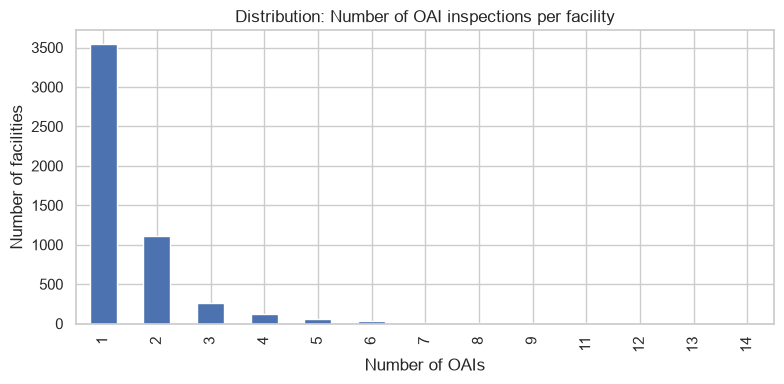

In [12]:
# Distribution of OAI count per facility
fig, ax = plt.subplots(figsize=(8, 4))
repeat_offenders["n_oai"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribution: Number of OAI inspections per facility")
ax.set_xlabel("Number of OAIs")
ax.set_ylabel("Number of facilities")
plt.tight_layout()
plt.savefig("../reports/fig_repeat_offenders_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Citations analysis

In [13]:
print(f"Total citations (in scope): {len(citations):,}")
print(f"Unique CFR codes: {citations['Act/CFR Number'].nunique()}")
print(f"\nTop 15 most cited regulations:")
print(citations["Act/CFR Number"].value_counts().head(15))

Total citations (in scope): 130,992
Unique CFR codes: 2335

Top 15 most cited regulations:
Act/CFR Number
21 CFR 820.100(a)    4316
21 CFR 820.198(a)    3895
FDCA 402(a)(4)       3614
21 CFR 211.192       2720
21 CFR 211.22(d)     2355
21 CFR 820.22        2147
21 CFR 312.60        2142
21 CFR 820.30(g)     1953
21 CFR 820.75(a)     1878
21 CFR 820.184       1789
21 CFR 820.90(a)     1778
21 CFR 211.100(a)    1734
21 CFR 803.17        1676
21 CFR 820.50        1623
21 CFR 211.160(b)    1408
Name: count, dtype: int64


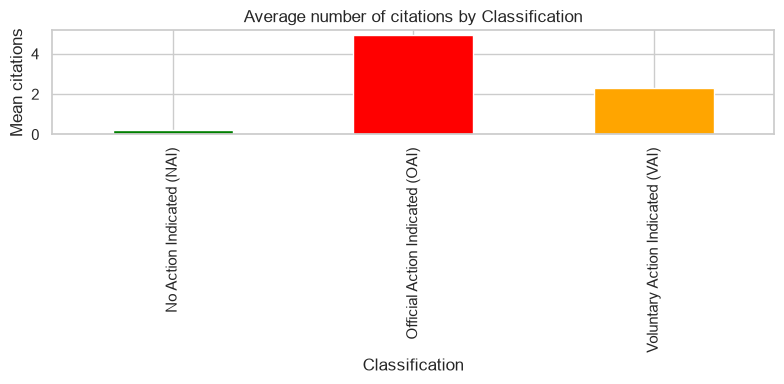

In [14]:
# Citations per inspection — does more citations correlate with OAI?
citation_counts = citations.groupby("Inspection ID").size().reset_index(name="n_citations")
inspections_with_cit = inspections.merge(citation_counts, on="Inspection ID", how="left")
inspections_with_cit["n_citations"] = inspections_with_cit["n_citations"].fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
inspections_with_cit.groupby("Classification")["n_citations"].mean().plot(
    kind="bar", ax=ax, color=["green", "red", "orange"]
)
ax.set_title("Average number of citations by Classification")
ax.set_ylabel("Mean citations")
plt.tight_layout()
plt.savefig("../reports/fig_citations_by_classification.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Citation presence as predictor signal
print("\n% of inspections with at least 1 citation, by classification:")
print(inspections_with_cit.groupby("Classification")["n_citations"].apply(lambda x: (x > 0).mean()))


% of inspections with at least 1 citation, by classification:
Classification
No Action Indicated (NAI)           0.066520
Official Action Indicated (OAI)     0.692158
Voluntary Action Indicated (VAI)    0.643212
Name: n_citations, dtype: float64


## 5. Warning letters overview

Warning letters (excl. tobacco): 2,410


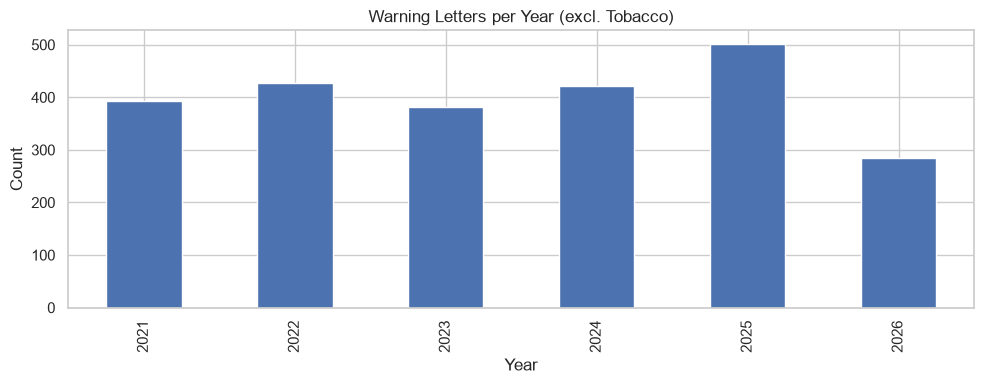

In [16]:
warning_letters["issue_date"] = pd.to_datetime(warning_letters["issue_date"])
warning_letters["year"] = warning_letters["issue_date"].dt.year

# Exclude tobacco (not relevant for Qualifyze's supply chain focus)
wl_filtered = warning_letters[
    ~warning_letters["issuing_office"].str.contains("Tobacco", case=False, na=False)
].copy()
print(f"Warning letters (excl. tobacco): {len(wl_filtered):,}")

fig, ax = plt.subplots(figsize=(10, 4))
wl_filtered.groupby("year").size().plot(kind="bar", ax=ax)
ax.set_title("Warning Letters per Year (excl. Tobacco)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/fig_warning_letters_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Subject categories
print("Top warning letter subjects (excl. tobacco):")
print(wl_filtered["subject"].value_counts().head(10))

Top warning letter subjects (excl. tobacco):


subject
CGMP/Finished Pharmaceuticals/Adulterated                                                                     335
Foreign Supplier Verification Program (FSVP)                                                                  302
Unapproved New Drugs/Misbranded                                                                               151
CGMP/QSR/Medical Devices/Adulterated                                                                           91
New Drug/Misbranded                                                                                            79
Unlawful Sale of Unapproved and Misbranded Drugs to United States Consumers Over the Internet (Telehealth)     63
Compounding Pharmacy/Adulterated Drug Products                                                                 58
Seafood HACCP/CGMP for Foods/Adulterated/Insanitary Conditions                                                 58
CGMP/Food/Prepared, Packed or Held Under Insanitary Conditions/Adulterated      

## 6. Enforcement / Recalls overview

In [18]:
print(f"Enforcement records: {len(enforcement):,}")
print(f"\nBy source:")
print(enforcement["_source"].value_counts())
print(f"\nBy classification:")
print(enforcement["classification"].value_counts())

Enforcement records: 57,203

By source:
_source
device    39430
drug      17773
Name: count, dtype: int64

By classification:
classification
Class II              49169
Class I                5308
Class III              2725
Not Yet Classified        1
Name: count, dtype: int64


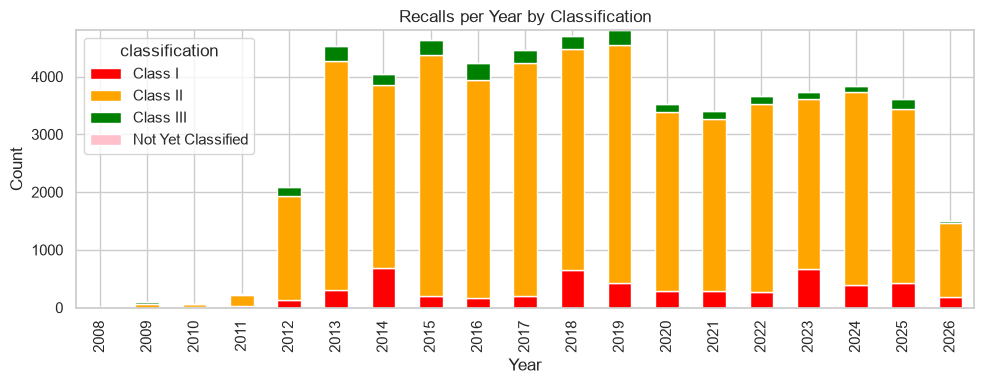

In [19]:
# Recalls over time
enforcement["recall_initiation_date"] = pd.to_datetime(
    enforcement["recall_initiation_date"], format="%Y%m%d", errors="coerce"
)
enforcement["year"] = enforcement["recall_initiation_date"].dt.year

fig, ax = plt.subplots(figsize=(10, 4))
enforcement[enforcement["year"] >= 2008].groupby(["year", "classification"]).size().unstack(fill_value=0).plot(
    kind="bar", stacked=True, ax=ax, color=["red", "orange", "green", "pink"]
)
ax.set_title("Recalls per Year by Classification")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/fig_recalls_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Key findings summary

1. **Class imbalance**: Only ~5-7% of inspections (excl. food) result in OAI
2. **Repeat offenders exist**: Some facilities have 5+ OAI inspections — strong predictive signal
3. **Citations correlate with severity**: OAI inspections have significantly more citations
4. **Geographic patterns**: Some countries have higher OAI rates
5. **Temporal trends**: OAI rate has varied over time — temporal validation is critical
6. **Multi-source signals**: Warning letters + recalls provide complementary risk indicators